# 03 — Model Training

## Architecture
```
Linear(n_features → 64) → ReLU → Dropout(0.1)
Linear(64 → 32) → ReLU
Linear(32 → 1)
```

## Training protocol
- Loss: Huber (δ=1.0) — robust to outlier bars
- Optimizer: Adam (lr=1e-3)
- Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
- Early stopping: patience=10 on val MAE
- Temporal split: 65% train / 15% val / 20% test
- Scaler fitted on train only (no data leakage)

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from features import FEATURE_NAMES
from pipeline import build_full_dataset
from train import train
from viz import plot_training_history, FIGURES_DIR

In [2]:
data, proxy_all, split = build_full_dataset()
print(f'Train: {len(split.X_train):,}  Val: {len(split.X_val):,}  Test: {len(split.X_test):,}')

[data] SPY: 3439 bars (2024-06-03 → 2026-05-22)
[data] QQQ: 3421 bars (2024-06-03 → 2026-05-22)
[data] AAPL: 3433 bars (2024-06-03 → 2026-05-22)
[data] MSFT: 3433 bars (2024-06-03 → 2026-05-22)
[data] NVDA: 3431 bars (2024-06-03 → 2026-05-22)
[data] AMZN: 3440 bars (2024-06-03 → 2026-05-22)
[data] GOOGL: 3438 bars (2024-06-03 → 2026-05-22)
[data] META: 3431 bars (2024-06-03 → 2026-05-22)
[data] JPM: 3441 bars (2024-06-03 → 2026-05-22)
Train: 39,933  Val: 9,215  Test: 12,288


In [3]:
model, history = train(
    split,
    n_features=len(FEATURE_NAMES),
    epochs=100,
    batch_size=256,
    lr=1e-3,
    patience=10,
    seed=42,
    verbose=True,
)
print(f'\nBest epoch: {history["best_epoch"]}  |  Best val MAE: {history["best_val_mae"]:.4f} bps')

Epoch 001  train_loss=26.4326  val_mae=23.5762


Epoch 010  train_loss=26.2321  val_mae=23.5830


Early stopping at epoch 12 (best epoch 2)
Model saved to /Users/francesconatale/Documents/projects/results/model_checkpoint.pt

Best epoch: 2  |  Best val MAE: 23.5651 bps


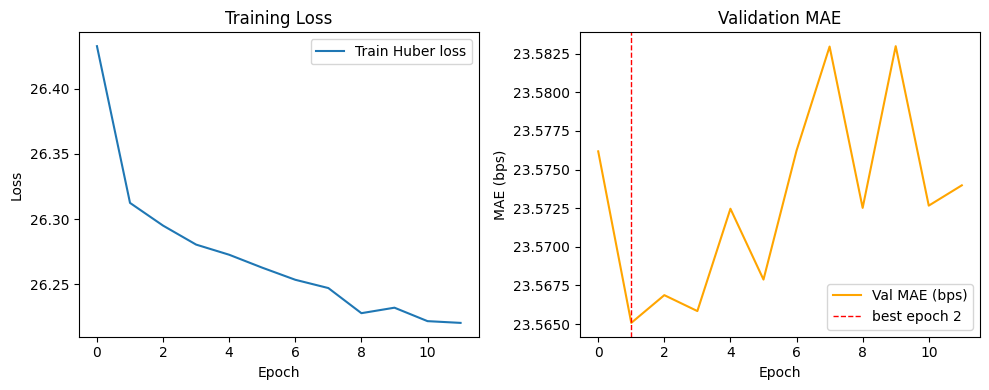

In [4]:
fig = plot_training_history(history, save_as='training_history.png')
plt.show()

In [5]:
# Save split metadata for notebook 04
import pickle
results_dir = pathlib.Path.cwd().parent / 'results'
results_dir.mkdir(exist_ok=True)
with open(results_dir / 'split_metadata.pkl', 'wb') as f:
    pickle.dump({'n_train': len(split.X_train), 'n_val': len(split.X_val), 'n_test': len(split.X_test)}, f)
print('Checkpoint and metadata saved.')

Checkpoint and metadata saved.
